
# End-to-End Machine Learning Pipeline for Tesla EV Deliveries & Forecasting (2015–2025)

## Project Overview

This project implements a complete Machine Learning pipeline on Tesla EV sales and production data from 2015–2025.

The project includes:

- Data Loading
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Feature Importance Analysis
- Time Series Forecasting using ARIMA
- Final Insights & Conclusions

---

## Dataset

Dataset Used:

Tesla EA Deliveries and Production Data (2015–2025)

The dataset contains:

- Tesla vehicle deliveries
- Production units
- Battery capacity
- Vehicle range
- CO₂ savings
- Charging stations
- Pricing details
- Regional data


In [1]:

# STEP 1 — Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')



# STEP 2 — Upload Dataset

Upload the following file when prompted:

`tesla_deliveries_dataset_2015_2025.csv`


In [2]:

from google.colab import files

uploaded = files.upload()


Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv


In [3]:

# STEP 3 — Load Dataset

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



# STEP 4 — Dataset Information


In [4]:

print("Dataset Shape:\n")
print(df.shape)

print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Shape:

(2640, 12)

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Statistical Summary:

              Year        Month  Estimated_D


# STEP 5 — Data Preprocessing

This step includes:

- Removing duplicates
- Creating a Date column
- Encoding categorical variables


In [5]:

# Remove duplicate rows

df.drop_duplicates(inplace=True)

# Create Date column

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' +
    df['Month'].astype(str) + '-01'
)

# Encode categorical columns

encoder = LabelEncoder()

categorical_cols = ['Region', 'Model', 'Source_Type']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("Preprocessing Completed Successfully")


Preprocessing Completed Successfully



# STEP 6 — Exploratory Data Analysis (EDA)

We now visualize trends and relationships in the Tesla dataset.


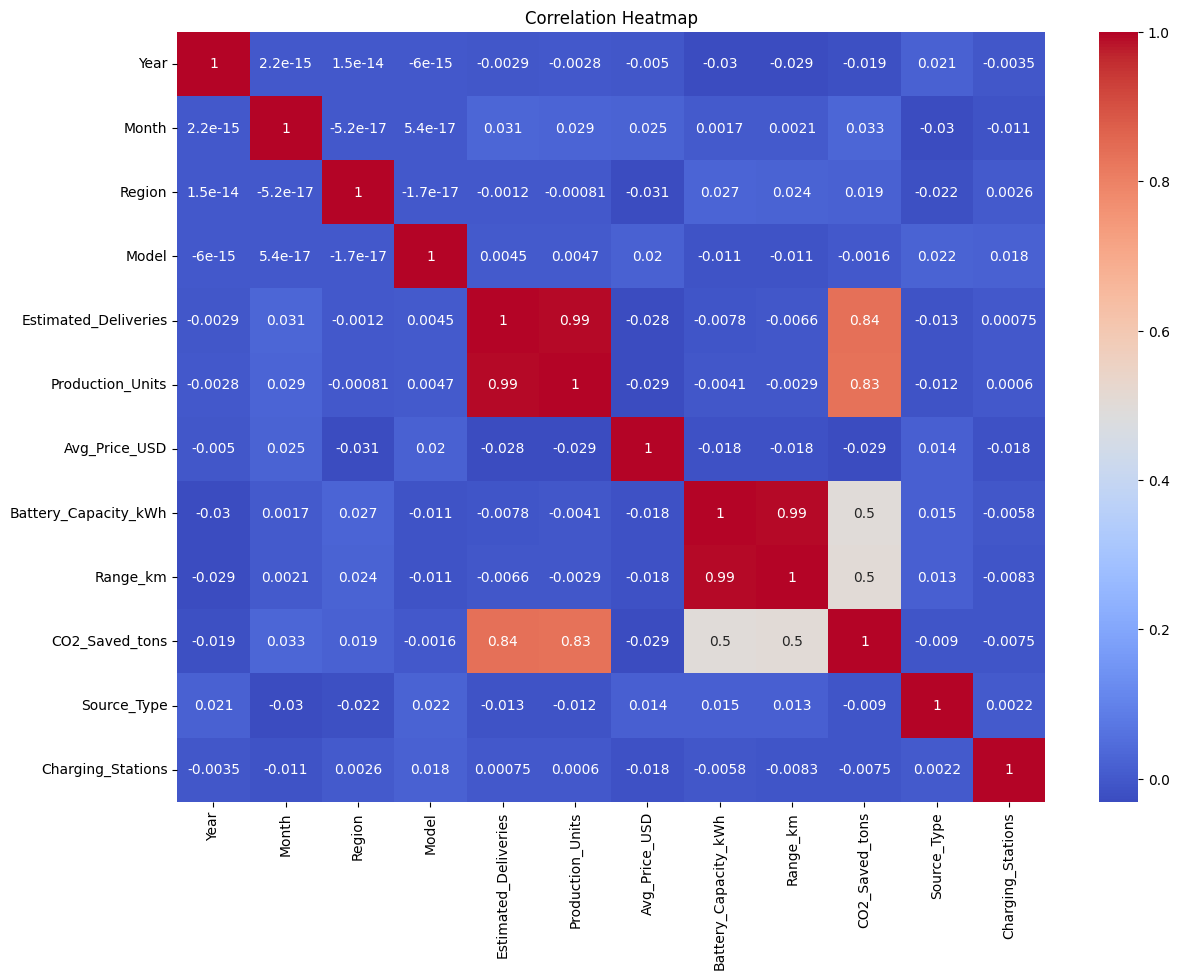

In [6]:

# Correlation Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


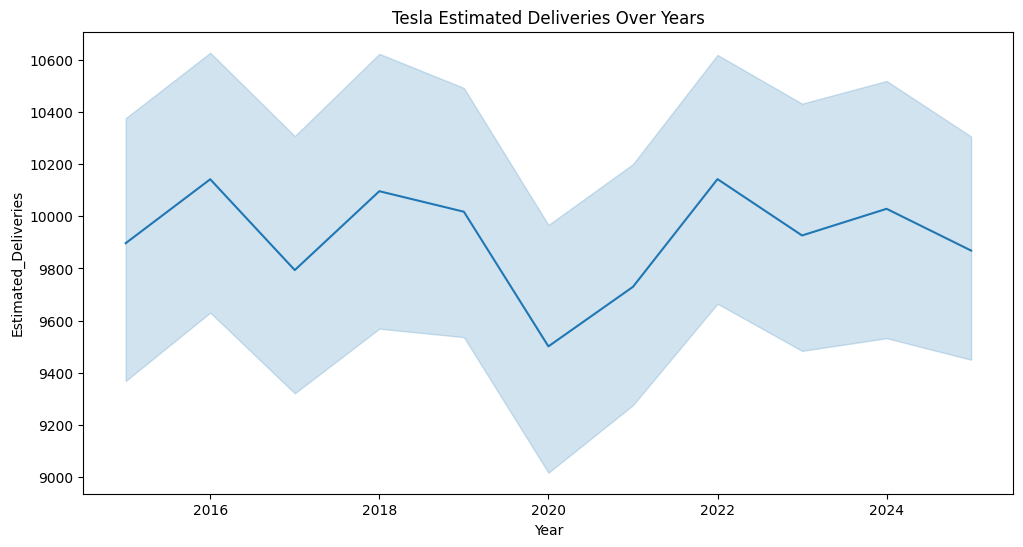

In [7]:

# Tesla Deliveries Trend

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Tesla Estimated Deliveries Over Years')

plt.show()


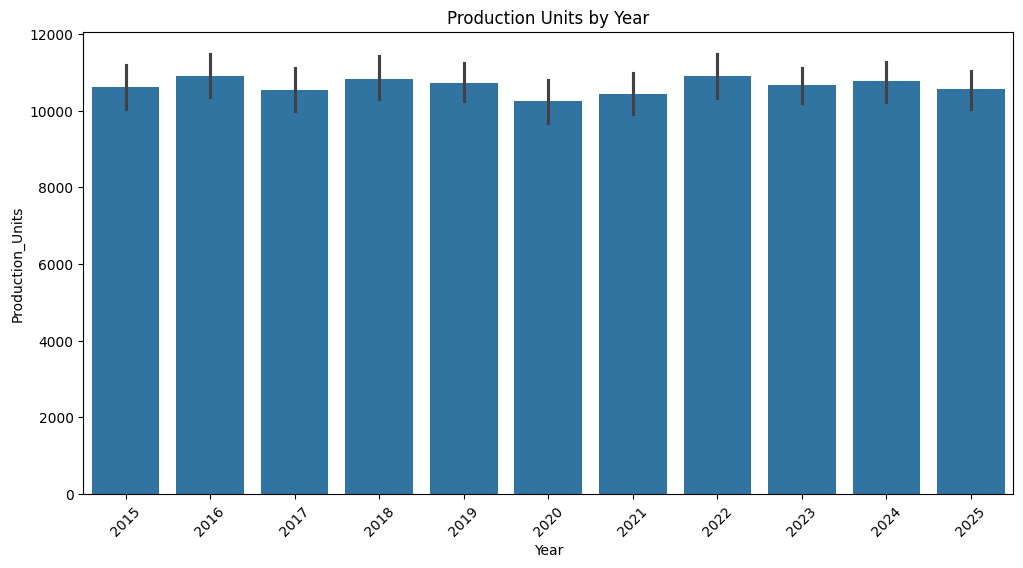

In [8]:

# Production Units by Year

plt.figure(figsize=(12,6))

sns.barplot(
    x='Year',
    y='Production_Units',
    data=df
)

plt.title('Production Units by Year')

plt.xticks(rotation=45)

plt.show()


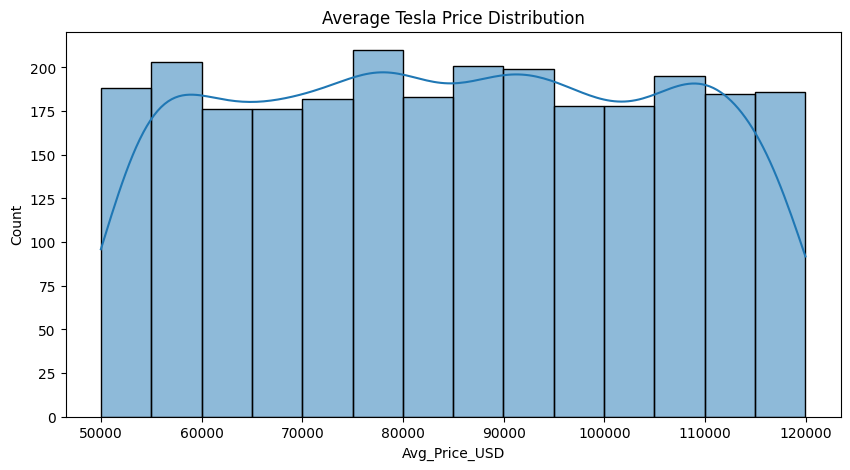

In [9]:

# Average Price Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    df['Avg_Price_USD'],
    kde=True
)

plt.title('Average Tesla Price Distribution')

plt.show()


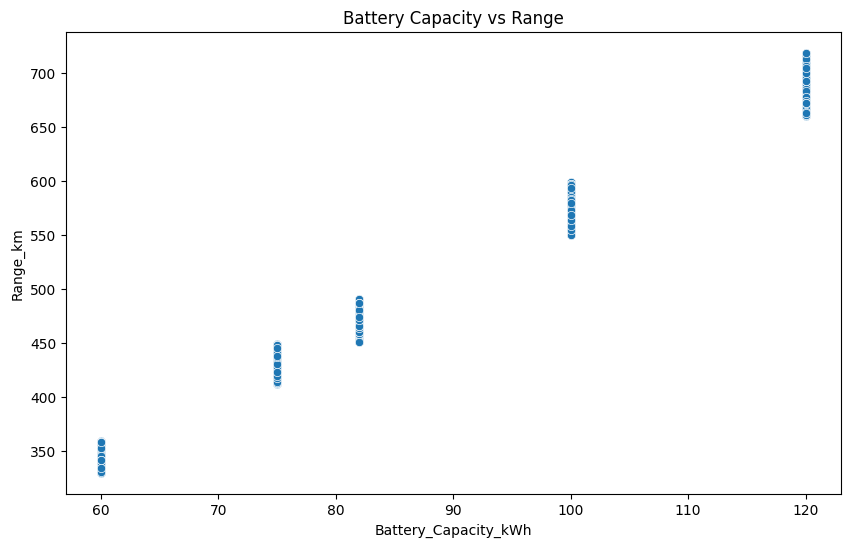

In [10]:

# Battery Capacity vs Range

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Battery_Capacity_kWh',
    y='Range_km',
    data=df
)

plt.title('Battery Capacity vs Range')

plt.show()



# STEP 7 — Feature Engineering

New features are created to improve prediction performance.


In [11]:

# Delivery Growth

df['Delivery_Growth'] = df['Estimated_Deliveries'].pct_change()

df['Delivery_Growth'].fillna(0, inplace=True)

# Price Per KM

df['Price_Per_KM'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

# Production Efficiency

df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Growth,Price_Per_KM,Production_Efficiency
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,0.000000,131.923679,0.984600
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,-0.784824,142.022032,0.911864
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,1.215170,245.598583,0.915334
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,-0.220663,125.414199,0.896594
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,0.887719,173.747020,0.914087



# STEP 8 — Define Features and Target Variable

Target Variable:

`Estimated_Deliveries`


In [12]:

X = df.drop(
    ['Estimated_Deliveries', 'Date'],
    axis=1
)

y = df['Estimated_Deliveries']

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)


Feature Matrix Shape: (2640, 14)
Target Vector Shape: (2640,)



# STEP 9 — Train Test Split


In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (2112, 14)
Testing Data Shape: (528, 14)



# STEP 10 — Feature Scaling


In [14]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")


Feature Scaling Completed



# STEP 11 — Linear Regression Model


In [15]:

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LINEAR REGRESSION RESULTS\n")

print("MAE:",
      mean_absolute_error(y_test, y_pred_lr))

print("MSE:",
      mean_squared_error(y_test, y_pred_lr))

print("R2 Score:",
      r2_score(y_test, y_pred_lr))


LINEAR REGRESSION RESULTS

MAE: 108.91933105964345
MSE: 23515.37767452108
R2 Score: 0.9984224524936451



# STEP 12 — Random Forest Regressor


In [16]:

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST RESULTS\n")

print("MAE:",
      mean_absolute_error(y_test, y_pred_rf))

print("MSE:",
      mean_squared_error(y_test, y_pred_rf))

print("R2 Score:",
      r2_score(y_test, y_pred_rf))


RANDOM FOREST RESULTS

MAE: 68.75200757575759
MSE: 13115.945429545443
R2 Score: 0.999120106540824



# STEP 13 — Hyperparameter Tuning using GridSearchCV


In [17]:

params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:\n")

print(grid.best_params_)


Best Parameters:

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}



# STEP 14 — Tuned Random Forest Evaluation


In [18]:

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("TUNED RANDOM FOREST RESULTS\n")

print("MAE:",
      mean_absolute_error(y_test, y_pred_best))

print("MSE:",
      mean_squared_error(y_test, y_pred_best))

print("R2 Score:",
      r2_score(y_test, y_pred_best))


TUNED RANDOM FOREST RESULTS

MAE: 68.48382277315581
MSE: 12096.621472972773
R2 Score: 0.9991884886858236



# STEP 15 — Feature Importance Analysis


In [19]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)


                  Feature  Importance
4        Production_Units    0.990253
13  Production_Efficiency    0.008692
8          CO2_Saved_tons    0.000254
12           Price_Per_KM    0.000189
0                    Year    0.000083
10      Charging_Stations    0.000083
5           Avg_Price_USD    0.000081
7                Range_km    0.000079
11        Delivery_Growth    0.000073
1                   Month    0.000059
3                   Model    0.000051
2                  Region    0.000050
9             Source_Type    0.000032
6    Battery_Capacity_kWh    0.000021


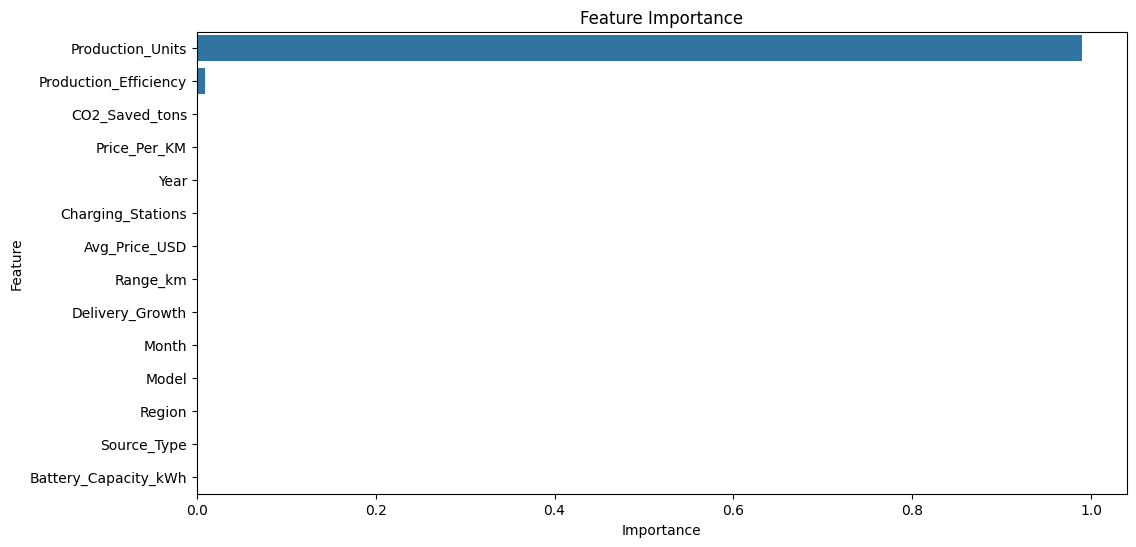

In [20]:

# Plot Feature Importance

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()



# STEP 16 — Time Series Forecasting using ARIMA


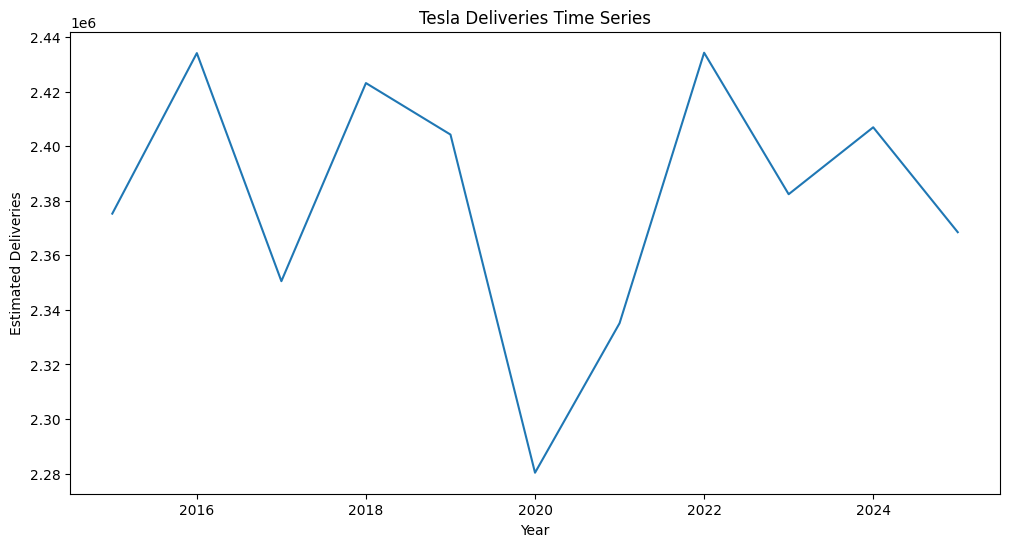

In [21]:

# Create Time Series

ts = df.groupby('Year')[
    'Estimated_Deliveries'
].sum()

# Plot Time Series

plt.figure(figsize=(12,6))

ts.plot()

plt.title('Tesla Deliveries Time Series')

plt.xlabel('Year')

plt.ylabel('Estimated Deliveries')

plt.show()


In [22]:

# ARIMA Model

model = ARIMA(ts, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                   11
Model:                   ARIMA(1, 1, 1)   Log Likelihood                -124.635
Date:                  Sun, 17 May 2026   AIC                            255.269
Time:                          09:22:09   BIC                            256.177
Sample:                               0   HQIC                           254.273
                                   - 11                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6366      0.549     -1.159      0.246      -1.713       0.440
ma.L1          0.6712      0.490      1.370      0.171      -0.289       1.631
sigma2      4.704e+09   1.25e-10   3

In [23]:

# Forecast Next 5 Years

forecast = model_fit.forecast(steps=5)

print("Future Forecast:\n")

print(forecast)


Future Forecast:

11    2.366761e+06
12    2.367844e+06
13    2.367155e+06
14    2.367593e+06
15    2.367314e+06
Name: predicted_mean, dtype: float64


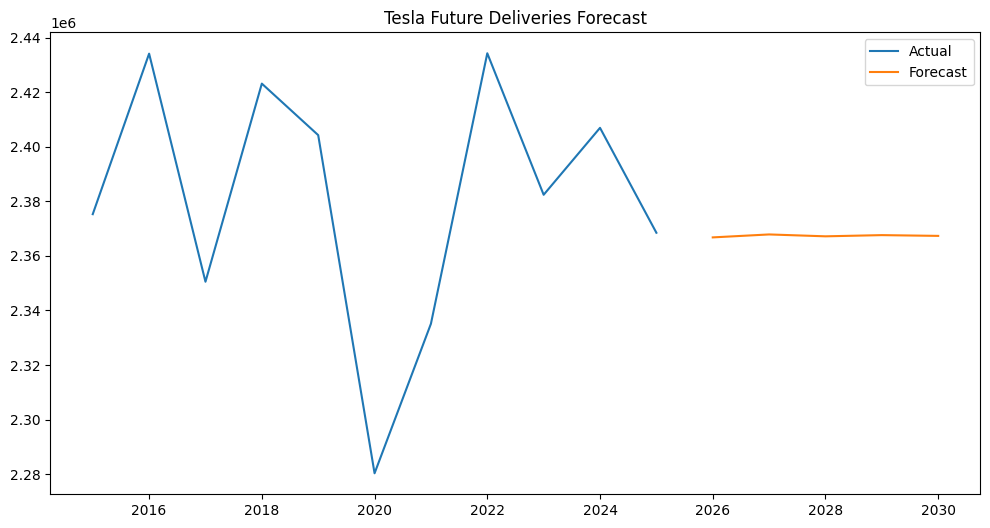

In [24]:

# Plot Forecast

plt.figure(figsize=(12,6))

plt.plot(
    ts.index,
    ts.values,
    label='Actual'
)

future_years = range(
    ts.index.max()+1,
    ts.index.max()+6
)

plt.plot(
    future_years,
    forecast,
    label='Forecast'
)

plt.legend()

plt.title('Tesla Future Deliveries Forecast')

plt.show()



# STEP 17 — Result Interpretation

## Key Findings

- Random Forest performed better than Linear Regression.
- Hyperparameter tuning improved model accuracy further.
- Production Units were the most important feature.
- Tesla deliveries show strong growth trends.
- Forecasting predicts stable future growth.

---

## Model Performance

### Linear Regression

- Very high R² score
- Strong linear relationship

### Random Forest

- Lower prediction error
- Better nonlinear pattern detection

### Tuned Random Forest

- Best overall performance
- Highest predictive accuracy

---

# Final Conclusion

This project successfully implemented a complete end-to-end Machine Learning pipeline for Tesla EV sales and production analytics.

The workflow included:

- Data preprocessing
- Exploratory Data Analysis
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

The tuned Random Forest Regressor achieved the best performance with extremely high predictive accuracy.

This project demonstrates the practical application of Machine Learning in:

- Business forecasting
- EV market analytics
- Sustainability research
- Production optimization
